In [6]:
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from neuralhydrology.datasetzoo import get_dataset, camelsus
from neuralhydrology.datautils.utils import load_scaler
from neuralhydrology.modelzoo.cudalstm import CudaLSTM
from neuralhydrology.modelzoo.shm import SHM
from neuralhydrology.nh_run import start_run
from neuralhydrology.utils.config import Config
from neuralhydrology.training.basetrainer import BaseTrainer
from neuralhydrology.modelzoo.cfe_modules import get_pet

### Train the LSTM
To start, let's train an lstm for a single basin. If you're curious this is for the Narraguagus River with flow as measured at Cherryfield, Maine. I chose this for consistency with `examples/05-Inspecting-LSTMs`

In [7]:
config_file = Path("1_basin.yml")

In [ ]:
config_file = Path("1_basin.yml")
# by default we assume that you have at least one CUDA-capable NVIDIA GPU or MacOS with Metal support
if torch.cuda.is_available() or torch.backends.mps.is_available():
     start_run(config_file=config_file)

 # fall back to CPU-only mode
else:
     start_run(config_file=config_file, gpu=-1)

### Load up trained model
The results of training (model weights, metadata, and optimizer-related data) are saved in `runs`. Let's load them up.

In [8]:
run_dir = Path("runs/test_run_0603_113658")  # this value comes from the output of the above command
#!ls $run_dir/model_epoch* | tail -n 3

### Load up trained model
Let's create a new instance of the neural network and then load the trained weights into it.

In [9]:
cudalstm_config = Config(config_file)

# create a new model instance with random weights
cuda_lstm = CudaLSTM(cfg=cudalstm_config)

# load the trained weights into the new model. 
model_path = run_dir / 'model_epoch030.pt'
model_weights = torch.load(str(model_path), map_location='cpu')  # load the weights from the file, creating the weight tensors on CPU
cuda_lstm.load_state_dict(model_weights)  # set the new model's weights to the values loaded from file
cuda_lstm

CudaLSTM(
  (embedding_net): InputLayer(
    (statics_embedding): Identity()
    (dynamics_embeddings): ModuleList(
      (0): Identity()
    )
  )
  (lstm): LSTM(5, 20)
  (dropout): Dropout(p=0.4, inplace=False)
  (head): Regression(
    (net): Sequential(
      (0): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

### Configuring SHM
Now, let's initialize an SHM model.

In [10]:
shm_config_file = Path("shm_config.yml")
shm_config = Config(shm_config_file)
shm = SHM(cfg=shm_config)

### Fetch the data
Lets instantiate a dataloader containing the data we want

In [ ]:
# this returns data that is shuffled by date
trainer = BaseTrainer(cfg = Config(config_file))
trainer.initialize_training()
loader = trainer.loader


In [11]:
scaler = load_scaler(run_dir )

In [12]:
#try to get data not shuffled
ds = get_dataset(cfg = Config(config_file), is_train = False, basin = "01022500", period = 'test', scaler=scaler)
ordered_data = DataLoader(ds, batch_size= 1, shuffle=False, num_workers= 8, collate_fn=ds.collate_fn)

In [13]:
data_point = next(iter(ordered_data))

In [14]:
print(data_point.keys())

dict_keys(['x_d', 'x_d_hindcast', 'x_d_forecast', 'y', 'date'])


In [ ]:
print(data_point['x_d'].keys())

In [ ]:
print(data_point['x_d']['tmax(C)'].shape)

In [ ]:
print(data_point['x_d']['tmax(C)'][0:5,0:2,:])

In [ ]:
print(data_point['y'].shape)
print(data_point['y'])

In [ ]:
print(data_point['date'].shape)
print(data_point['date'])


In [15]:
shm_parameters = {
            "dd": torch.tensor(5.0, device="cpu", dtype=torch.float32),
            "f_thr": torch.tensor(10.0, device="cpu", dtype=torch.float32),
            "sumax": torch.tensor(25.0, device="cpu", dtype=torch.float32),
            "beta": torch.tensor(5.0, device="cpu", dtype=torch.float32),
            "perc": torch.tensor(0.5, device="cpu", dtype=torch.float32),
            "kf": torch.tensor(3.0, device="cpu", dtype=torch.float32),
            "ki": torch.tensor(5.0, device="cpu", dtype=torch.float32),
            "kb": torch.tensor(15.0, device="cpu", dtype=torch.float32),
        }

In [ ]:
ss, sf, su, si, sb = shm.initialize_states(batch_size=256, device = 'cpu')

In [16]:
def make_linear_M(ss, sf, su, si, sb, shm_parameters, x_conceptual_timestep, device):
    n_basins = ss.shape[0]
    M = torch.zeros(n_basins, 6, 6)
    M[:,5,5] =1
    zeros = torch.zeros_like(ss)
    ones = torch.ones_like(ss)

    # auxiliary vectors
    t_mean = (x_conceptual_timestep[:, 2] + x_conceptual_timestep[:, 3]) / 2
    temp_mask = t_mean < 0 # True when it is freezing
    snow_melt = t_mean * shm_parameters["dd"]
    snow_melt = torch.where(temp_mask, zeros, snow_melt) #torch.where(condition, input, other, *, out=None) → Tensor Return a tensor of elements selected from either input or other, depending on condition.
    
    klu = torch.tensor(0.90, device=device, dtype=torch.float32)

    # liquid precipitation:
    liquid_p = torch.where(temp_mask, zeros, x_conceptual_timestep[:,0])

    # solid precipitation (snow):
    snow = torch.where(temp_mask, x_conceptual_timestep[:,0], zeros)

    # permanent wilting point use in ET:
    pwp = 0.8 * shm_parameters["sumax"]

    # Snow module --------------------------
    qs_out = torch.minimum(ss, snow_melt) #cant melt more snow than there is
    qsp_out = qs_out + liquid_p

    M[:,0,0] = torch.where(snow_melt > ss, zeros, ones)
    M[:,0,5] = torch.where(snow_melt > ss, zeros, -snow_melt)

    
    dqsp_dss = torch.where(snow_melt> ss, ones, zeros) #if all the snow melts, then liquid is ss + P

    # Split snowmelt+rainfall into inflow to fastflow reservoir and unsaturated reservoir ------
    qf_in = torch.maximum(torch.tensor(0.0), qsp_out - shm_parameters["f_thr"])
    qu_in = torch.minimum(qsp_out, ones*shm_parameters["f_thr"])

    dqf_dss = torch.where(qsp_out > ones*shm_parameters["f_thr"], dqsp_dss, zeros) # if the liquid is greater than the saturation threshold then fast flow depends on liquid
    dqu_dss = torch.where(qsp_out > ones*shm_parameters["f_thr"], zeros, dqsp_dss) # if the liquid is less than the saturation threshold, then the unsaturated zone depends on liquid


    # Fastflow module ----------------------
    #    sf = (sf + qf_in) - (sf + qf_in) / shm_parameters["kf"] = (1 - 1/shm_parameters["kf"])(sf + qf_in)
    M[:, 1,0] = (1 - 1/shm_parameters["kf"])*dqf_dss # if liquid is ss
    M[:, 1,1] = (1 - 1/shm_parameters["kf"])
    M[:, 1,5] = (1 - 1/shm_parameters["kf"])*(qf_in - dqf_dss*ss) # 

    # Unsaturated zone----------------------
    psi = (su / shm_parameters["sumax"]) ** shm_parameters["beta"]
    dpsi_dsu = (shm_parameters["beta"]/shm_parameters["sumax"])*(su / shm_parameters["sumax"]) ** (shm_parameters["beta"]-1)
    su_temp = su + qu_in * (1 - psi)
    su = torch.minimum(su_temp, ones*shm_parameters["sumax"])

    dsut1_dsu = torch.where(su_temp > ones*shm_parameters["sumax"], zeros, 1 - qu_in*dpsi_dsu)
    dsut1_dss = torch.where(su_temp > ones*shm_parameters["sumax"], zeros, dqu_dss*(1-psi))
    su_const = torch.where(su_temp > ones*shm_parameters["sumax"], ones*shm_parameters["sumax"], qu_in*psi)

    qu_out = qu_in * psi + torch.maximum(torch.tensor(0.0), su_temp - shm_parameters["sumax"])  # [mm]
    dqu_out_dsu = torch.where(su_temp > ones*shm_parameters["sumax"], ones, qu_in*dpsi_dsu)
    dqu_out_dss = torch.where(su_temp > ones*shm_parameters["sumax"], dqu_dss, dqu_dss*psi)


    # Evapotranspiration -------------------
    # su_new = max(0, su_new - ret)
    ktetha = su / shm_parameters["sumax"]
    et_mask = su <= pwp
    ktetha[~et_mask] = torch.ones_like(ktetha[~et_mask]) # ktetha = su/sumax if su < pwp otherwise 1
    #if self.cfg.dataset == "camels_us":
    #    pet = get_pet.daily_pet_jensen2016(
    #        T_avg=t_mean,
    #        S_rad=x_conceptual_timestep[:, 1],
    #    ).to(device)
    #else:
    #    pet = x_conceptual_timestep[:, :, 1]
    pet = x_conceptual_timestep[:, 1]
    ret = pet * klu * ktetha  # [mm]
    dret_dsu = torch.where(su < pwp , ones*pet*klu/shm_parameters["sumax"], zeros)
    dsut1_dsu = dsut1_dsu - dret_dsu
    su_const = torch.where(su < pwp, su_const, su_const - ret)
    #su = torch.maximum(torch.tensor(0.0), su - ret)  if all the water evaporates# [mm]
    dsut1_dsu = torch.where((su - ret) > 0, dsut1_dsu, zeros)
    dsut1_dss = torch.where((su - ret) > 0, dsut1_dss, zeros)
    su_const = torch.where((su - ret) >0, su_const, zeros)

    M[:,2,0] = dsut1_dss
    M[:,2,2] = dsut1_dsu
    M[:,2,5] = su_const - dsut1_dss*ss - dsut1_dsu*su



    # Interflow reservoir ------------------
    #si = (si + qu_out * shm_parameters["perc"])*( 1 - 1/ shm_parameters["ki"])  # [mm]
    M[:,3,0] = (1 - 1/shm_parameters["ki"])*shm_parameters["perc"]*dqu_out_dss
    M[:,3,2] = (1 - 1/shm_parameters["ki"])*shm_parameters["perc"]*dqu_out_dsu
    M[:,3,3] = (1 - 1/shm_parameters["ki"])
    M[:,3,5] =  (1 - 1/shm_parameters["ki"])*shm_parameters["perc"]*(qu_out - dqu_out_dsu*su - dqu_out_dss*ss)

    # Baseflow reservoir -------------------
    #sb = (sb + qu_out * (1.0 - shm_parameters["perc"]))(1 - 1/shm_parameters["kb"])
    M[:,4,0] = (1 - 1/shm_parameters["kb"])*(1 - shm_parameters["perc"])*dqu_out_dss
    M[:,4,2] = (1 - 1/shm_parameters["kb"])*(1 - shm_parameters["perc"])*dqu_out_dsu
    M[:,4,4] = (1 - 1/shm_parameters["kb"])
    M[:,4,5] =  (1 - 1/shm_parameters["kb"])*(1 - shm_parameters["perc"])*(qu_out - dqu_out_dsu*su - dqu_out_dss*ss)

    return M


In [ ]:

# SCRATCH WORK CODDE BELOW, doesnt work
#conceptual vars
T = 0 #make these something
P = 0 #x_conceptual_timestep ?
c = 0 #?? center for phi approx,use last value of su_t?
pet = 0 

#xt = [ss,sf,su,si,sb, 1]
#  ss
#  sf
#  su
#  si
#  sb
# 1 to add constants
# multiplying xt by M gives xt+1
M = torch.ones(6,6)*3.5
M[5, :] = torch.tensor([0,0,0,0,0,1]) # to keep the last element 1

if T > 0: # not freezing
    if T*shm_parameters["dd"] > ss: #all snow melts
        ## qsp_out = ss + P 
        M[0, :] = torch.tensor([0, 0, 0, 0, 0, 0]) 
        if (ss + P) > shm_parameters["f_thr"]: #above saturation threshhold so some goes to fast flow
            sf_1 = (sf + ss + P - shm_parameters["f_thr"])*(1 - 1/shm_parameters["kf"])
            M[1,:] =  torch.tensor([(1 - 1/shm_parameters["kf"]), (1 - 1/shm_parameters["kf"]), 0, 0, 0,(1 - 1/shm_parameters["kf"])*(P-shm_parameters["f_thr"])] )
            phi_ish = (c/shm_parameters["sumax"])**shm_parameters["beta"] + (shm_parameters["beta"]/shm_parameters["sumax"])*(c/shm_parameters["sumax"])**(shm_parameters["beta"]-1)
            su = su + ss + P 
            if su < (0.8*shm_parameters["sumax"]): # determine ret 
                ret = pet*0.9*su/shm_parameters["sumax"]
            else:
                ret = pet*0.9
        else: #unsaturated zone is not full
            sf_1 = (sf)*(1 - 1/shm_parameters["kf"])
        
    else: #not all snow melts
        ## qsp_out = T*shm_parameters["dd"] + P #
        ss_1 = ss - T*shm_parameters["dd"]
        if (T*shm_parameters["dd"] + P) > shm_parameters["f_thr"]: #above saturation threshold
            sf_1 = (sf + T*shm_parameters["dd"] + P - shm_parameters["f_thr"])*(1 - 1/shm_parameters["kf"])
        else: #unsaturated zone is not full
            sf_1 = (sf)*(1 - 1/shm_parameters["kf"])

else: # freezing
    ss_1 = ss + P
    M[0, :] = torch.tensor([1,0,0,0,0,P])
    
    


In [ ]:
## ToDo:
# 1. Fetch decent parameters, or make them up.
# 1.5 initialize the data loader. 
# 2. use shm.timestep in a for loop.
# 3. How do I connect this to forcings?

In [ ]:
#Test make linear M
t = 0
t_mean = (data_point['x_d']['tmax(C)'][:, t] + data_point['x_d']['tmin(C)'][:, t])/2
pet = get_pet.daily_pet_jensen2016(
                T_avg=t_mean,
                S_rad=data_point['x_d']['srad(W/m2)'][:,t],
            )
x_conceptual_timestep = torch.stack([
    data_point['x_d']['prcp(mm/day)'][:, t],
    pet,
    data_point['x_d']['tmin(C)'][:, t],
    data_point['x_d']['tmax(C)'][:, t],
], dim=1)
x_conceptual_timestep = x_conceptual_timestep.squeeze(-1)

M = make_linear_M(ss,sf,su,si,sb,shm_parameters, x_conceptual_timestep, device = "cpu")
print(M[1,:,:])

In [ ]:
# for loop

pt = data_point #ordered_data[1]
dates = pt['date'] #[1,365]
ys = pt['y'] #[1,365,1]
x_d = pt['x_d'] # dict of forcing params mapped to [1,365,1]

cuda_lstm.eval()
with torch.no_grad():
    z = cuda_lstm(pt) # "true" value from the lstm

# intitialize states for shm, total guess??
x = torch.tensor([0.0,1.0,5.0,10.0,15.0],dtype = torch.float32, device = "cpu")
x_history = np.zeros((6,365))

for j in range(ys.shape[1]): #each day
    date = dates[0, j]
    y = ys[0 ,j, 0] # true observed outflow not needed but could compare
    pet = get_pet.daily_pet_jensen2016(
                T_avg=(x_d['tmax(C)'][0, j,0] + x_d['tmin(C)'][0, j,0])/2,
                S_rad= x_d['srad(W/m2)'][0,j,0],
            )
    x_conceptual_timestep = np.stack([x_d["prcp(mm/day)"][0,j,0], pet, x_d["tmin(C)"][0,j,0], x_d["tmax(C)"][0,j,0]])
    x_conceptual_timestep = torch.tensor(x_conceptual_timestep, dtype = torch.float32, device = "cpu").unsqueeze(dim = 0)
    print(x_conceptual_timestep.shape)
    
    x[0], x[1], x[2], x[3], x[4], z_minus = shm.timestep_shm(x[0], x[1], x[2], x[3], x[4], shm_parameters, x_conceptual_timestep, device = x_conceptual_timestep.device)
    for i in range(4):
        x_history[i,j] = x[i]
    x_history[5] = z_minus

print(x)        

shape of ys is 365
torch.Size([1, 4])
0
0
0
0
torch.Size([1, 4])
1
1
1
1
torch.Size([1, 4])
2
2
2
2
torch.Size([1, 4])
3
3
3
3
torch.Size([1, 4])
4
4
4
4
torch.Size([1, 4])
5
5
5
5
torch.Size([1, 4])
6
6
6
6
torch.Size([1, 4])
7
7
7
7
torch.Size([1, 4])
8
8
8
8
torch.Size([1, 4])
9
9
9
9
torch.Size([1, 4])
10
10
10
10
torch.Size([1, 4])
11
11
11
11
torch.Size([1, 4])
12
12
12
12
torch.Size([1, 4])
13
13
13
13
torch.Size([1, 4])
14
14
14
14
torch.Size([1, 4])
15
15
15
15
torch.Size([1, 4])
16
16
16
16
torch.Size([1, 4])
17
17
17
17
torch.Size([1, 4])
18
18
18
18
torch.Size([1, 4])
19
19
19
19
torch.Size([1, 4])
20
20
20
20
torch.Size([1, 4])
21
21
21
21
torch.Size([1, 4])
22
22
22
22
torch.Size([1, 4])
23
23
23
23
torch.Size([1, 4])
24
24
24
24
torch.Size([1, 4])
25
25
25
25
torch.Size([1, 4])
26
26
26
26
torch.Size([1, 4])
27
27
27
27
torch.Size([1, 4])
28
28
28
28
torch.Size([1, 4])
29
29
29
29
torch.Size([1, 4])
30
30
30
30
torch.Size([1, 4])
31
31
31
31
torch.Size([1, 4])
32
32
32
3

/var/folders/_3/t73nmd891rq3_4ccyv1xw5740000gn/T/ipykernel_31264/3187459306.py:32: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x_history[5] = z_minus


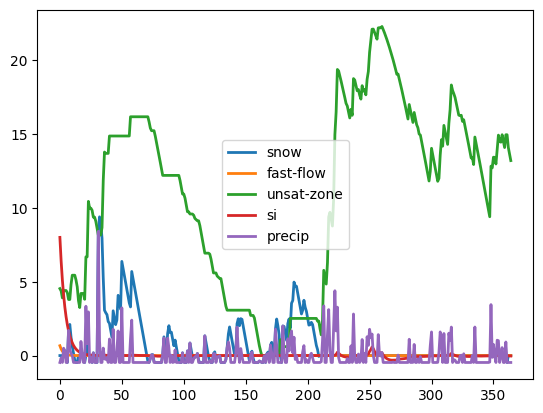

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)  # (rows, cols, index)
plt.plot(x_d["prcp(mm/day)"][0,:,0],label="precip",linewidth=2.0)
T_avg=(x_d['tmax(C)'][0, :,0] + x_d['tmin(C)'][0, :,0])/2
plt.plot(T_avg, label="av. Temp (in C)", linewidth=2.0)
plt.title('Meteorogical Forcings')
plt.legend()

plt.subplot(1, 2, 2) 
plt.plot(x_history[0,:],label='snow',linewidth=2.0)
plt.plot(x_history[1,:],label='fast-flow',linewidth=2.0)
plt.plot(x_history[2,:],label='unsat-zone',linewidth=2.0)
plt.plot(x_history[3,:],label='si',linewidth=2.0)
plt.legend()
plt.title("States")

plt.show()

In [26]:
print(x_history)

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.66666663 0.         0.         ... 0.         0.         0.        ]
 [4.532516   0.         0.         ... 0.         0.         0.        ]
 [7.9999404  0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [3.33331347 3.33331347 3.33331347 ... 3.33331347 3.33331347 3.33331347]]
